
# 5. Experiment 1 — Vanilla RNN


In [3]:
import pandas as pd

df_clean = pd.read_csv("../data/cleaned_data.csv")

df_clean["date"] = pd.to_datetime(df_clean["date"])
df_clean = df_clean.iloc[:, 1:3]
df_clean.head()

,date,demand
0,2015-01-01,99635.030
1,2015-01-02,129606.010
2,2015-01-03,142300.540
3,2015-01-04,104330.715
4,2015-01-05,118132.200


In [2]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2106 non-null   datetime64[us]
 1   demand  2106 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 33.0 KB


In [4]:
import torch
import torch.nn as nn

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

RNN formula:

$$
h_t = \tanh(W_xx_t + W_hh_{t-1} + b)
$$

hidden_size example:
"At this point in the sequence, what 32 numbers summarize what I've seen so far?"

In [15]:
# code without PyTorch built-in RNN
class ElectricityDemandRNN(nn.Module):
    """Vanilla RNN implemented from scratch using PyTorch tensors."""

    def __init__(self, input_size: int, hidden_size: int, output_size: int):
        """
        Args:
            input_size: How many features come into the RNN at one timestep.
            hidden_size: How much information the RNN keeps in its memory.
            output_size: How many values you want the model to predict.
        """
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        # RNN recurrence learnable weights and biases                
        self.W_xh = nn.Parameter(torch.randn(input_size, hidden_size))  # Weight applied to current input      
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size)) # Weight that transforms the previous hidden state to the current hidden state
        self.b_h = nn.Parameter(torch.zeros(hidden_size))

        # Output Layer learnable weights and biases
        self.W_hy = nn.Parameter(torch.randn(hidden_size, output_size)) # Weight that transforms the current hidden state into a prediction
        self.b_y = nn.Parameter(torch.zeros(output_size))


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Process each input sequence timestep by timestep and use the
        final hidden state to make one prediction per sequence.

        Args:
            x: Input sequence with shape
                (batch_size, sequence_length, input_size).

        Returns:
            One prediction per sequence with shape
            (batch_size, output_size).
        """

        batch_size, sequence_length, _ = x.shape

        # h_0: no previous information at the beginning.
        h_previous = torch.zeros(batch_size, self.hidden_size, device=x.device)

        for t in range(sequence_length):

            # For every sequence across the entire batch, give me all features at timestep t
            x_t = x[:, t, :]

            # RNN recurrence.
            # comput the current hidden state
            h_t = torch.tanh(
                x_t @ self.W_xh
                + h_previous @ self.W_hh
                + self.b_h
            )

            # The current hidden state becomes
            # the previous hidden state for the next timestep
            h_previous = h_t

        # convert hidden state into a prediction. Many-to-one
        # After processing the entire sequence, then use the final hidden state to make ONE prediction.
        # y_t shape = (batch_size, output_size) = (2, 1)
        y_t = h_t @ self.W_hy + self.b_y

        return y_t



# Training

Use the previous 7 days of demand to predict the next day's demand.

X = previous 7 days
y = next day

The logic:
```
i = 0

X[0] = days 1 → 7
y[0] = day 8

i = 1

X[1] = days 2 → 8
y[1] = day 9

i = 2

X[2] = days 3 → 9
y[2] = day 10
```

In [5]:
import numpy as np

## Chronical Train/test split

In [6]:
# train-test split

df = df_clean.set_index("date")
df = df.sort_index()

# since demand is my only feature
values = df["demand"].values

n = len(values)

train_end = int(0.8 * n)

train_values = values[:train_end]
test_values = values[train_end:]


print(f"Train: {len(train_values)}")
print(f"Test: {len(test_values)}")

Train: 1684
Test: 422


## Data Transformation

In [7]:
# try min-max scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(
    train_values.reshape(-1, 1)
)
test_scaled = scaler.transform(
    test_values.reshape(-1, 1)
)
print(np.shape(train_scaled))
print(np.shape(test_scaled))

(1684, 1)
(422, 1)


## create the 7d sliding window

In [8]:

SEQUENCE_LENGTH = 7


def create_sequences(values: np.ndarray, sequence_length: int):
    """
    Create sliding-window sequences for next-day forecasting.

    Example with sequence_length=7:

        X = days 1-7
        y = day 8

        X = days 2-8
        y = day 9
    """

    X = []
    y = []

    for i in range(len(values) - sequence_length):
        X.append(values[i : i + sequence_length])

        y.append(values[i + sequence_length])

    return np.array(X), np.array(y)




In [ ]:
X_train, y_train = create_sequences(train_scaled, SEQUENCE_LENGTH)
X_test, y_test = create_sequences(test_scaled, SEQUENCE_LENGTH)

print(np.shape(X_train))
print(np.shape(y_train))


## Convert to PyTorch Tensors

In [58]:
# rnn expects: (batch_size, sequence_length, input_size)
# create_sequences already preserves the feature dim from the (N, 1) scaled arrays,
# so X is already (N, seq_len, 1) and y is already (N, 1) — no unsqueeze needed.
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(X_train.shape)
print(y_train.shape)

torch.Size([1677, 7, 1])
torch.Size([1677, 1])


In [59]:
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


X_test: torch.Size([415, 7, 1])
y_test: torch.Size([415, 1])


## Data Loader

In [10]:
BATCH_SIZE = 64

from torch.utils.data import DataLoader, TensorDataset


In [ ]:

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Create the model

In [61]:
train_scaled.shape

(1684, 1)

In [11]:


INPUT_SIZE = train_scaled.shape[-1]   # 1
OUTPUT_SIZE = train_scaled.shape[-1]  # 1
HIDDEN_SIZE = 32

EPOCHS = 10

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))



In [ ]:
model = ElectricityDemandRNN(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE).to(device)
criterion = nn.L1Loss()  # pytorch's MAE
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [63]:
for name, param in model.named_parameters():
    print(name, param.shape)


W_xh torch.Size([1, 32])
W_hh torch.Size([32, 32])
b_h torch.Size([32])
W_hy torch.Size([32, 1])
b_y torch.Size([1])


## Training Loop

In [9]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):

    model.train()

    total_loss = 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = model(x_batch)

        loss = criterion(y_pred, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    return avg_loss

## Train for multiple Epochs

In [65]:
for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model=model,
        train_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    print(f"Epoch {epoch + 1}/{EPOCHS} | Loss: {train_loss:.4f}")

Epoch 1/10 | Loss: 2.4018
Epoch 2/10 | Loss: 0.8631
Epoch 3/10 | Loss: 0.4576
Epoch 4/10 | Loss: 0.3304
Epoch 5/10 | Loss: 0.2555
Epoch 6/10 | Loss: 0.2099
Epoch 7/10 | Loss: 0.1850
Epoch 8/10 | Loss: 0.1670
Epoch 9/10 | Loss: 0.1493
Epoch 10/10 | Loss: 0.1397


## Evaluate

In [10]:
def evaluate_model(model, data_loader, scaler, device):
    """
    Run the model on a data loader and return predictions/targets
    in the ORIGINAL demand scale, plus real-unit MAE/RMSE.
    """

    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)

            y_pred = model(x_batch)

            all_preds.append(y_pred.cpu())
            all_targets.append(y_batch.cpu())

    preds_scaled = torch.cat(all_preds).numpy()
    targets_scaled = torch.cat(all_targets).numpy()

    # undo min-max scaling to get back to real demand units
    preds = scaler.inverse_transform(preds_scaled)
    targets = scaler.inverse_transform(targets_scaled)

    test_mae = mae(targets, preds)
    test_rmse = rmse(targets, preds)

    return preds, targets, test_mae, test_rmse



In [ ]:
preds, targets, test_mae, test_rmse = evaluate_model(model, test_loader, scaler, device)

print(f"Test MAE:  {test_mae:,.2f} demand units")
print(f"Test RMSE: {test_rmse:,.2f} demand units")


In [ ]:
# TODO:
# rec both train perf, and test perf. to see how it's learning?

## Sweep: sequence length vs. performance

Repeat the full pipeline (sequence creation → tensors → loader → fresh model → train → evaluate) for `sequence_length` in `[7, 14, 30, 60]`, and record MAE, RMSE, training time, and inference latency for each.

In [14]:
import time


def run_experiment(sequence_length: int, hidden_size: int = HIDDEN_SIZE,
                    epochs: int = EPOCHS, batch_size: int = BATCH_SIZE,
                    lr: float = 0.001, seed: int = 42):
    """
    Build sequences, train a fresh ElectricityDemandRNN, and evaluate it
    for a given sequence_length. Returns a dict of results.

    train_scaled / test_scaled / scaler / device are reused from the
    outer scope (already fit on the chronological train/test split).
    """

    torch.manual_seed(seed)

    # 1. sliding-window sequences for this sequence_length
    X_tr, y_tr = create_sequences(train_scaled, sequence_length)
    X_te, y_te = create_sequences(test_scaled, sequence_length)

    # 2. tensors — already (N, seq_len, 1) / (N, 1), no unsqueeze needed
    X_tr = torch.tensor(X_tr, dtype=torch.float32)
    y_tr = torch.tensor(y_tr, dtype=torch.float32)
    X_te = torch.tensor(X_te, dtype=torch.float32)
    y_te = torch.tensor(y_te, dtype=torch.float32)

    # 3. loaders
    train_loader_exp = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=False)
    test_loader_exp = DataLoader(TensorDataset(X_te, y_te), batch_size=batch_size, shuffle=False)

    # 4. fresh model per run so results aren't contaminated by earlier training
    model_exp = ElectricityDemandRNN(INPUT_SIZE, hidden_size, OUTPUT_SIZE).to(device)
    criterion_exp = nn.L1Loss()
    optimizer_exp = torch.optim.Adam(model_exp.parameters(), lr=lr)

    # 5. train, timing the whole training run
    train_start = time.perf_counter()
    for _ in range(epochs):
        train_one_epoch(
            model=model_exp,
            train_loader=train_loader_exp,
            criterion=criterion_exp,
            optimizer=optimizer_exp,
            device=device,
        )
    train_time = time.perf_counter() - train_start

    # 6. evaluate + inference latency (ms per sample, single-sample batches)
    single_loader = DataLoader(TensorDataset(X_te, y_te), batch_size=1, shuffle=False)
    model_exp.eval()
    with torch.no_grad():
        infer_start = time.perf_counter()
        for x_batch, _ in single_loader:
            model_exp(x_batch.to(device))
        infer_time = time.perf_counter() - infer_start
    latency_ms = (infer_time / len(single_loader.dataset)) * 1000

    _, _, test_mae, test_rmse = evaluate_model(model_exp, test_loader_exp, scaler, device)

    return {
        "sequence_length": sequence_length,
        "mae": test_mae,
        "rmse": test_rmse,
        "training_time_s": train_time,
        "inference_latency_ms": latency_ms,
    }

In [15]:
SEQUENCE_LENGTHS = [1, 7, 14, 30, 60]

results = [run_experiment(seq_len) for seq_len in SEQUENCE_LENGTHS]

results_df = pd.DataFrame(results).set_index("sequence_length")
results_df

,mae,rmse,training_time_s,inference_latency_ms
sequence_length,,,,
1,7760.540527,10122.441406,3.258786,1.066827
7,19860.886719,43534.234375,3.518814,2.223256
14,269685.406250,336429.000000,4.256513,3.198894
30,306027.218750,371054.718750,7.748473,5.957185
60,263662.218750,330736.875000,13.204792,12.850017


## Diagnostic: is the sequence-length blowup exploding gradients?

MAE jumps from ~7.7k (seq=1) to ~270-306k (seq=14/30) and back down to ~264k (seq=60) — that non-monotonic explosion looks like training instability, not vanishing gradients (which would plateau near the short-window result, not diverge past the demand range). Before reaching for `clip_grad_norm_` as a fix, confirm the mechanism: log the pre-clip gradient norm per batch using `max_norm=float("inf")`, which computes and returns the total gradient norm **without actually clipping anything**. If grad norm stays small/flat at seq=1 but spikes or grows sharply at seq=14/30/60 — especially where the loss also blows up — that confirms exploding gradients.

This is a diagnostic add-on, not a replacement for `train_one_epoch`/`run_experiment` above — those stay as the recorded baseline results.

In [12]:
def train_one_epoch_with_grad_norm(model, train_loader, criterion, optimizer, device):
    """
    Same as train_one_epoch, but also records the pre-clip gradient norm
    for every batch. max_norm=inf makes clip_grad_norm_ a no-op — it still
    computes and returns the total norm, it just never rescales gradients.
    """

    model.train()

    total_loss = 0
    grad_norms = []

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = model(x_batch)

        loss = criterion(y_pred, y_batch)

        loss.backward()

        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float("inf"))
        grad_norms.append(grad_norm.item())

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    return avg_loss, grad_norms

In [17]:
def run_experiment_diagnostic(sequence_length: int, hidden_size: int = HIDDEN_SIZE,
                               epochs: int = EPOCHS, batch_size: int = BATCH_SIZE,
                               lr: float = 0.001, seed: int = 42):
    """
    Same pipeline as run_experiment, but trains with train_one_epoch_with_grad_norm
    and returns per-epoch loss + gradient-norm stats instead of final test metrics,
    so we can see WHEN training destabilizes, not just the end result.
    """

    torch.manual_seed(seed)

    X_tr, y_tr = create_sequences(train_scaled, sequence_length)
    X_tr = torch.tensor(X_tr, dtype=torch.float32)
    y_tr = torch.tensor(y_tr, dtype=torch.float32)

    train_loader_exp = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=False)

    model_exp = ElectricityDemandRNN(INPUT_SIZE, hidden_size, OUTPUT_SIZE).to(device)
    criterion_exp = nn.L1Loss()
    optimizer_exp = torch.optim.Adam(model_exp.parameters(), lr=lr)

    epoch_losses = []
    epoch_grad_norm_mean = []
    epoch_grad_norm_max = []

    for _ in range(epochs):
        avg_loss, grad_norms = train_one_epoch_with_grad_norm(
            model=model_exp,
            train_loader=train_loader_exp,
            criterion=criterion_exp,
            optimizer=optimizer_exp,
            device=device,
        )
        epoch_losses.append(avg_loss)
        epoch_grad_norm_mean.append(np.mean(grad_norms))
        epoch_grad_norm_max.append(np.max(grad_norms))

    return {
        "sequence_length": sequence_length,
        "epoch_losses": epoch_losses,
        "epoch_grad_norm_mean": epoch_grad_norm_mean,
        "epoch_grad_norm_max": epoch_grad_norm_max,
    }

SEQUENCE_LENGTHS = [1, 7, 14, 30, 60]

diagnostic_results = [run_experiment_diagnostic(seq_len) for seq_len in SEQUENCE_LENGTHS]

for r in diagnostic_results:
    print(f"seq_len={r['sequence_length']:>3} | "
          f"final loss={r['epoch_losses'][-1]:.4f} | "
          f"mean grad norm (last epoch)={r['epoch_grad_norm_mean'][-1]:.4f} | "
          f"max grad norm (last epoch)={r['epoch_grad_norm_max'][-1]:.4f}")

seq_len=  1 | final loss=0.0946 | mean grad norm (last epoch)=1.0523 | max grad norm (last epoch)=2.7691
seq_len=  7 | final loss=0.2087 | mean grad norm (last epoch)=13.9723 | max grad norm (last epoch)=31.4567
seq_len= 14 | final loss=3.3779 | mean grad norm (last epoch)=1951.8638 | max grad norm (last epoch)=5130.4121
seq_len= 30 | final loss=3.6300 | mean grad norm (last epoch)=2969100.9579 | max grad norm (last epoch)=10777405.0000
seq_len= 60 | final loss=3.4233 | mean grad norm (last epoch)=62838054952329.8438 | max grad norm (last epoch)=1087583564070912.0000


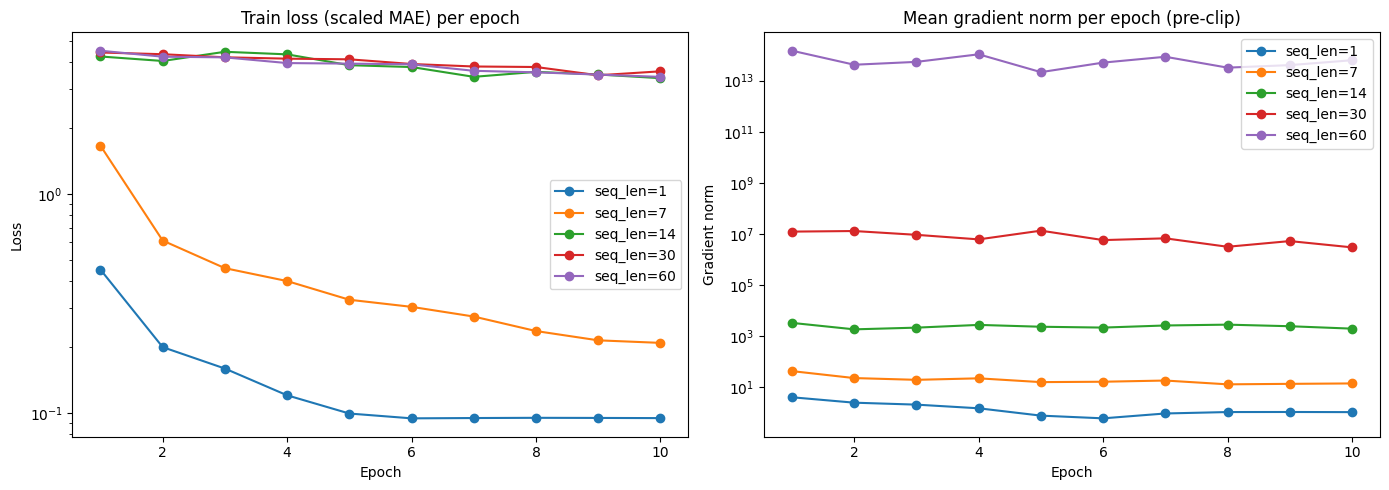

In [18]:
import matplotlib.pyplot as plt

fig, (ax_loss, ax_grad) = plt.subplots(1, 2, figsize=(14, 5))

for r in diagnostic_results:
    label = f"seq_len={r['sequence_length']}"
    ax_loss.plot(range(1, EPOCHS + 1), r["epoch_losses"], marker="o", label=label)
    ax_grad.plot(range(1, EPOCHS + 1), r["epoch_grad_norm_mean"], marker="o", label=label)

ax_loss.set_title("Train loss (scaled MAE) per epoch")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss")
ax_loss.set_yscale("log")
ax_loss.legend()

ax_grad.set_title("Mean gradient norm per epoch (pre-clip)")
ax_grad.set_xlabel("Epoch")
ax_grad.set_ylabel("Gradient norm")
ax_grad.set_yscale("log")
ax_grad.legend()

fig.tight_layout()
plt.show()